# NBA Salary vs Performance Analysis

This project analyzes whether NBA players' salaries are justified by their performance.

Key questions:
- Do higher salaries lead to better performance?
- Are there diminishing returns?
- Which players provide the best value for money?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

In [2]:
try:
    salary_df = pd.read_csv("nba_salaries_2023.csv")
    print("Data loaded successfully")
except FileNotFoundError:
    print("File not found, using sample data")
    salary_df = pd.DataFrame({
        "Player": ["Player A", "Player B", "Player C"],
        "Salary": [30000000, 20000000, 10000000],
        "Points": [25, 18, 10]
    })

Data loaded successfully


In [3]:
salary_df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,STL,BLK,TOV,PF,PTS,Awards,Player-additional,Season Type,PER,Adjusted Salary
0,1,Joel Embiid,28,PHI,C,66.0,66.0,34.6,11.0,20.1,...,1.0,1.7,3.4,3.1,33.1,MVP-1DPOY-9CPOY-5ASNBA1,embiijo01,Regular,31.4,35605377.25
1,2,Luka Dončić,23,DAL,PG,66.0,66.0,36.2,10.9,22.0,...,1.4,0.5,3.6,2.5,32.4,MVP-8CPOY-8ASNBA1,doncilu01,Regular,28.7,39290951.43
2,3,Damian Lillard,32,POR,PG,58.0,58.0,36.3,9.6,20.7,...,0.9,0.3,3.3,1.9,32.2,CPOY-10ASNBA3,lillada01,Regular,26.7,45006144.50
3,4,Shai Gilgeous-Alexander,24,OKC,PG,68.0,68.0,35.5,10.4,20.3,...,1.6,1.0,2.8,2.8,31.4,MVP-5CPOY-7ASNBA1,gilgesh01,Regular,27.2,32742459.52
4,5,Giannis Antetokounmpo,28,MIL,PF,63.0,63.0,32.1,11.2,20.3,...,0.8,0.8,3.9,3.1,31.1,MVP-3DPOY-6ASNBA1,antetgi01,Regular,29.0,45006144.50


In [4]:
salary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rk                 896 non-null    int64  
 1   Player             896 non-null    object 
 2   Age                896 non-null    int64  
 3   Team               896 non-null    object 
 4   Pos                896 non-null    object 
 5   G                  896 non-null    float64
 6   GS                 896 non-null    float64
 7   MP                 896 non-null    float64
 8   FG                 896 non-null    float64
 9   FGA                896 non-null    float64
 10  FG%                896 non-null    float64
 11  3P                 896 non-null    float64
 12  3PA                896 non-null    float64
 13  3P%                896 non-null    float64
 14  2P                 896 non-null    float64
 15  2PA                896 non-null    float64
 16  2P%                896 non

In [5]:
salary_df.describe()

,Rk,Age,G,GS,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,PER,Adjusted Salary
count,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,...,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,8.960000e+02
mean,284.054688,26.273438,34.770089,16.146205,19.498884,3.235826,6.957924,0.453565,0.989397,2.790848,...,2.616741,3.455692,1.979687,0.589509,0.372656,1.058594,1.652455,8.820312,12.515402,9.545675e+06
std,199.758665,4.364152,26.484540,23.653831,10.455678,2.542242,5.220315,0.132219,0.894995,2.309452,...,1.882299,2.496516,1.962165,0.430151,0.400837,0.870108,0.865086,7.088298,7.877857,1.133050e+07
min,1.000000,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-50.500000,6.195000e+03
25%,112.750000,23.000000,8.000000,0.000000,11.500000,1.400000,3.100000,0.406000,0.200000,0.900000,...,1.300000,1.600000,0.700000,0.300000,0.100000,0.500000,1.000000,3.700000,9.575000,2.214894e+06
50%,231.500000,25.000000,30.000000,4.000000,18.800000,2.500000,5.600000,0.453000,0.800000,2.400000,...,2.200000,3.000000,1.300000,0.500000,0.300000,0.800000,1.600000,6.900000,12.900000,4.699472e+06
75%,455.250000,29.000000,60.000000,22.000000,28.325000,4.400000,9.400000,0.504000,1.500000,4.300000,...,3.525000,4.600000,2.700000,0.800000,0.500000,1.400000,2.200000,12.000000,16.100000,1.213497e+07
max,679.000000,42.000000,83.000000,83.000000,42.400000,12.800000,24.800000,1.000000,4.900000,12.100000,...,11.700000,14.100000,10.700000,3.000000,3.100000,4.700000,5.000000,34.500000,65.600000,5.091361e+07


In [6]:
print(salary_df.columns)

Index(['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'Awards', 'Player-additional', 'Season Type', 'PER', 'Adjusted Salary'],
      dtype='object')


In [7]:
# Drop rows with any missing values
salary_df = salary_df.dropna()

# Define column names (must match your dataset exactly)
salary_col = "Adjusted Salary"
points_col = "PTS"

# Calculate points per million dollars of salary
# Use np.where to avoid division by zero errors
salary_df["Points_per_Million"] = np.where(
    salary_df[salary_col] > 0,
    salary_df[points_col] / (salary_df[salary_col] / 1_000_000),
    0
)

# Initialize MinMaxScaler for normalization
scaler = MinMaxScaler()

# Normalize the salary values to a 0-1 range
# Use double brackets to keep the data in 2D format required by scaler
salary_df["Normalized_Salary"] = scaler.fit_transform(
    salary_df[[salary_col]]
)

# Print the first 5 rows to verify the new columns
print("Data processing completed. New columns added:")
print(salary_df[[points_col, salary_col, "Points_per_Million", "Normalized_Salary"]].head())

Data processing completed. New columns added:
    PTS  Adjusted Salary  Points_per_Million  Normalized_Salary
0  33.1      35605377.25            0.929635           0.699293
1  32.4      39290951.43            0.824617           0.771690
2  32.2      45006144.50            0.715458           0.883957
3  31.4      32742459.52            0.958999           0.643055
4  31.1      45006144.50            0.691017           0.883957


In [8]:
# Calculate the correlation between salary and points
correlation = salary_df[[salary_col, points_col]].corr()
print("Correlation between Salary and Points:")
print(correlation)

Correlation between Salary and Points:
                 Adjusted Salary       PTS
Adjusted Salary         1.000000  0.715238
PTS                     0.715238  1.000000


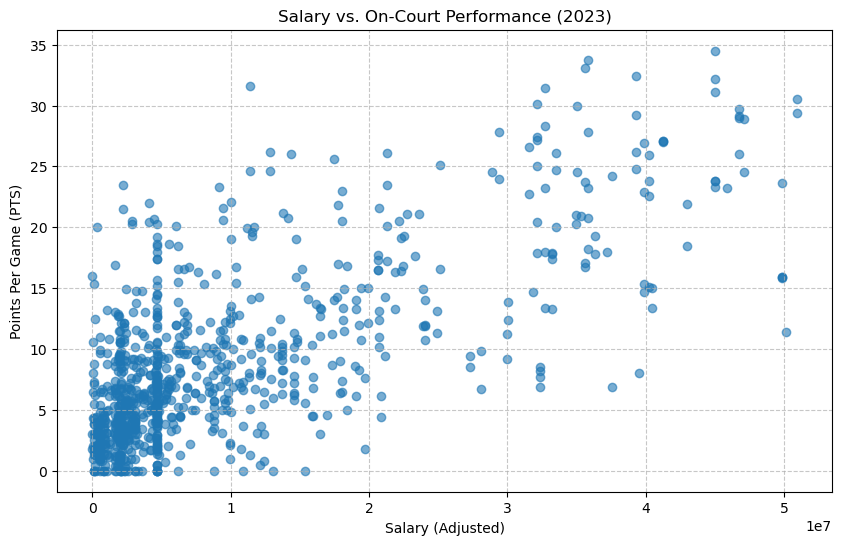

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(salary_df[salary_col], salary_df[points_col], alpha=0.6)
plt.xlabel("Salary (Adjusted)")
plt.ylabel("Points Per Game (PTS)")
plt.title("Salary vs. On-Court Performance (2023)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

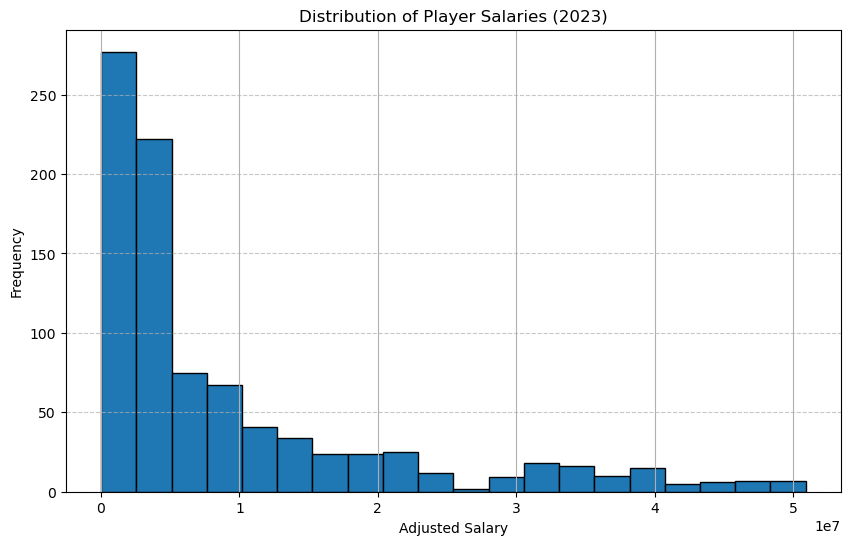

In [10]:
plt.figure(figsize=(10, 6))
salary_df[salary_col].hist(bins=20, edgecolor="black")
plt.title("Distribution of Player Salaries (2023)")
plt.xlabel("Adjusted Salary")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

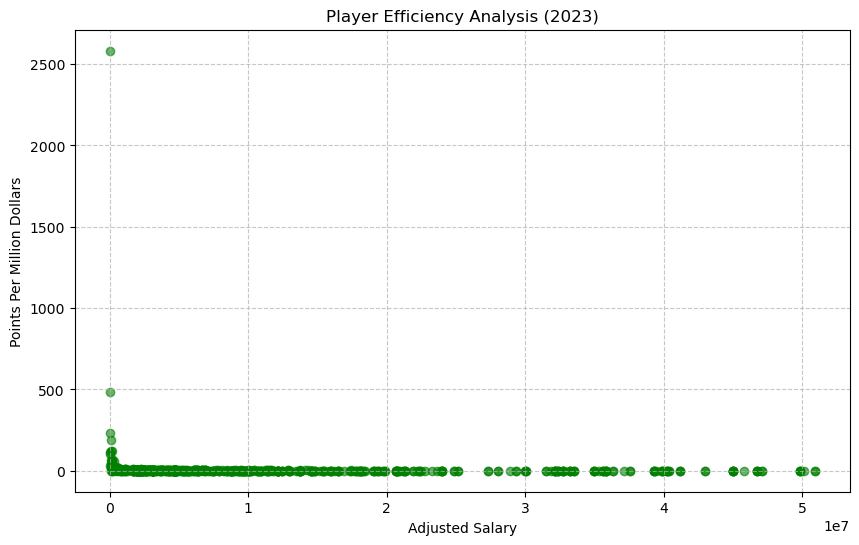

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(salary_df[salary_col], salary_df["Points_per_Million"], alpha=0.6, color="green")
plt.xlabel("Adjusted Salary")
plt.ylabel("Points Per Million Dollars")
plt.title("Player Efficiency Analysis (2023)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [12]:
# Prepare data for linear regression
X = salary_df[[salary_col]]
y = salary_df[points_col]

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print model coefficients
print("Linear Regression Results:")
print(f"Slope: {model.coef_[0]:.6f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R-squared: {model.score(X, y):.4f}")

Linear Regression Results:
Slope: 0.000000
Intercept: 4.55
R-squared: 0.5116


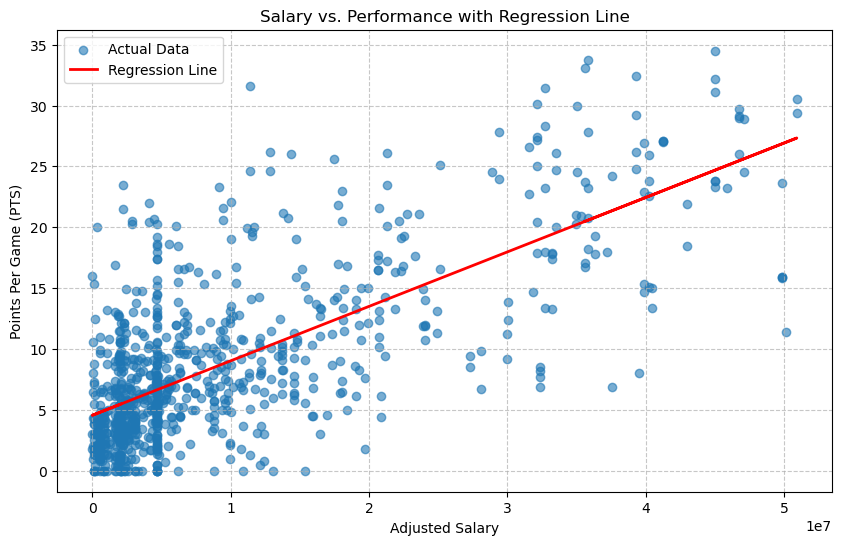

In [13]:
plt.figure(figsize=(10, 6))
# Plot the scatter points
plt.scatter(salary_df[salary_col], salary_df[points_col], alpha=0.6, label="Actual Data")

# Generate predictions for the regression line
predictions = model.predict(X)
# Plot the regression line
plt.plot(salary_df[salary_col], predictions, color="red", linewidth=2, label="Regression Line")

plt.xlabel("Adjusted Salary")
plt.ylabel("Points Per Game (PTS)")
plt.title("Salary vs. Performance with Regression Line")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

## Analysis & Insights
1. There is a positive relationship between salary and performance, but the correlation is not extremely strong.
2. Some high-salary players do not significantly outperform lower-paid players, indicating market inefficiencies.
3. The efficiency metric (Points per Million) shows that some lower-paid players provide much better value.
4. Teams should consider both cost and performance metrics when evaluating player contracts.

## Conclusion
Salary is an important factor, but not the only determinant of on-court performance.
Efficient allocation of salary can lead to better team performance and financial flexibility.
This highlights the importance of data-driven contract evaluation in professional sports.